# CNN_SignMNIST_Pretrained_DenseNet

### Sign MNIST를 3 Conv Layer + ReLU + Dropout을 이용한 CNN으로 구현하라
### (Colab을 사용하는 경우 "files/sign_mnist" 폴더를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_11_CNN_SignMNIST_3_Conv_Layer_ReLU_Dropout/files/sign_mnist/'
else :
  files_path = '../files/sign_mnist/'

In [4]:
# csv에서 이미지 읽기
import csv
def get_data(filename):
    with open(filename) as training_file:
        reader = csv.reader(training_file, delimiter=',')
        imgs = []
        labels = []

        next(reader, None)

        for row in reader:
            label = row[0]
            data = row[1:]
            img = np.array(data).reshape((28, 28))

            imgs.append(img)
            labels.append(label)

        images = np.array(imgs).astype(np.float32)
        labels = np.array(labels).astype(np.float32)
    return images, labels

training_data, training_labels = get_data(files_path + 'sign_mnist_train/sign_mnist_train.csv')
testing_data, testing_labels = get_data(files_path + 'sign_mnist_test/sign_mnist_test.csv')

In [5]:
print(training_data.shape)
print(training_labels.shape)
print(training_labels[:10])
print(testing_data.shape)
print(testing_labels.shape)
print(testing_labels[:10])

(27455, 28, 28)
(27455,)
[ 3.  6.  2.  2. 13. 16.  8. 22.  3.  3.]
(7172, 28, 28)
(7172,)
[ 6.  5. 10.  0.  3. 21. 10. 14.  3.  7.]


In [6]:
# 1. train_data, train_labels, test_data, test_labels 준비
train_data = np.expand_dims(training_data, axis=-1)
test_data = np.expand_dims(testing_data, axis=-1)
train_labels = training_labels
test_labels = testing_labels

print(train_data.shape)
print(train_labels.shape)
print(train_labels[:10])
print(test_data.shape)
print(test_labels.shape)
print(test_labels[:10])

(27455, 28, 28, 1)
(27455,)
[ 3.  6.  2.  2. 13. 16.  8. 22.  3.  3.]
(7172, 28, 28, 1)
(7172,)
[ 6.  5. 10.  0.  3. 21. 10. 14.  3.  7.]


In [7]:
# 2. 전처리: 0 ~ 1로 변환
train_data = train_data / 255.0
test_data = test_data / 255.0

In [8]:
# 3. Keras Model 정의, Model summary
IMG_SIZE = 28
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,1)))
# conv 1
model.add(tf.keras.layers.Conv2D(64,3,padding='same',activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.4))                          #  DO1
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
# conv 2
model.add(tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.4))                          # DO2
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
# conv 3
model.add(tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.4))                           # DO3
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
# dense layers
model.add(tf.keras.layers.Flatten(name='flatten'))
model.add(tf.keras.layers.Dense(26, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 26)                  │          15,002 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,498 (349.60 KB)

 Trainable params: 89,498 (349.60 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 4. Model compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# 5. Make_Result_Plot() 함수 정의 -> 정답과 예측값을 알파뱃으로 출력
alpha = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
def Make_Result_Plot(suptitle:str, data:np.ndarray, label:np.ndarray, y_max:np.ndarray):
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        ax_result[idx//5,idx%5].imshow(data[idx].reshape((IMG_SIZE,IMG_SIZE)), cmap='gray')
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(idx, alpha[int(label[idx])], alpha[y_max[idx, 0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


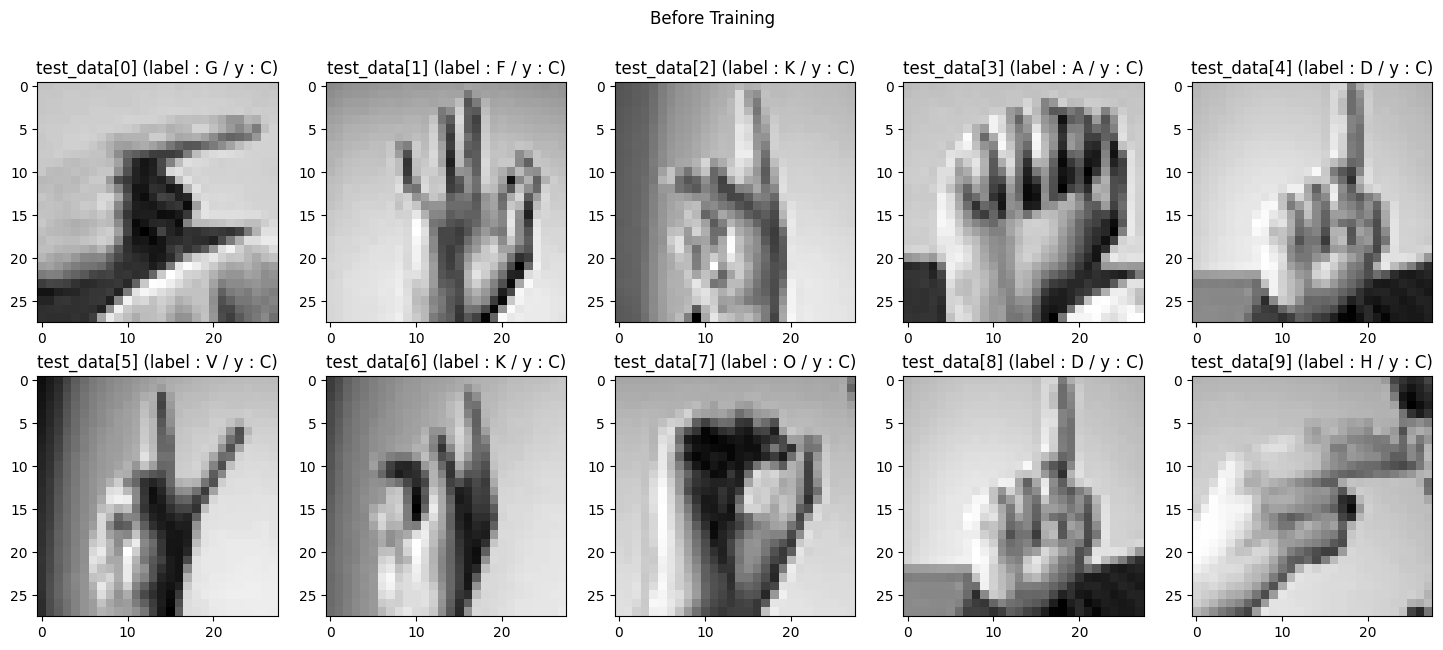

In [11]:
# 6. 학습 전 상황 그리기
y_out = model.predict(test_data[:10])
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

In [12]:
# 7. Model fit

In [13]:
%%time
history = model.fit(train_data, train_labels, epochs=10,
                 validation_data=(test_data, test_labels) )

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.3825 - loss: 2.0511 - val_accuracy: 0.9023 - val_loss: 0.7027
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9174 - loss: 0.2327 - val_accuracy: 0.9564 - val_loss: 0.3332
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9633 - loss: 0.1072 - val_accuracy: 0.9530 - val_loss: 0.2521
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9790 - loss: 0.0635 - val_accuracy: 0.9665 - val_loss: 0.1744
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9850 - loss: 0.0442 - val_accuracy: 0.9738 - val_loss: 0.1690
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9874 - loss: 0.0367 - val_accuracy: 0.9598 - val_loss: 0.1788
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9875 - loss: 0.0376 - val_accuracy: 0.9710 - val_loss: 0.1322
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9914 - loss: 0.0262 - val_accuracy: 

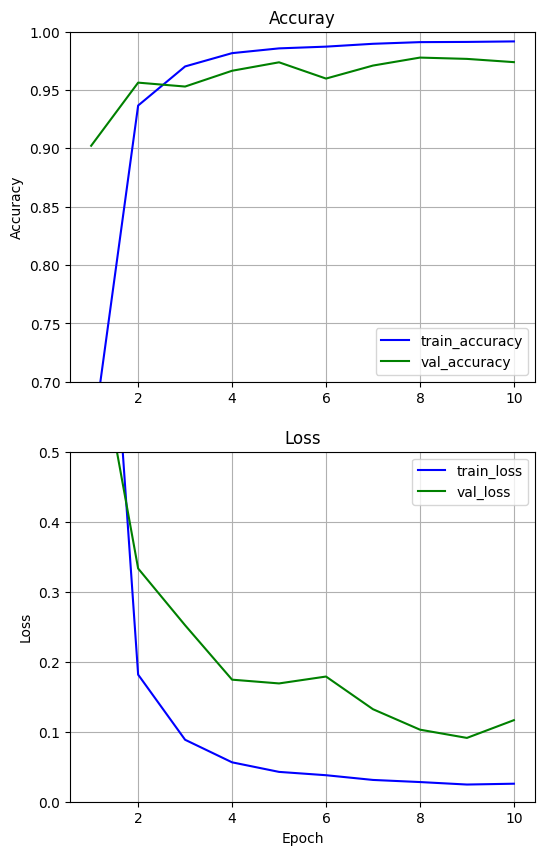

In [14]:
# 8. accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'g', label='val_accuracy')
plt.ylim([0.7,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.plot(epochs, history.history['val_loss'], 'g', label='val_loss')
plt.ylim([0,0.5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

> ### Training 이후

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


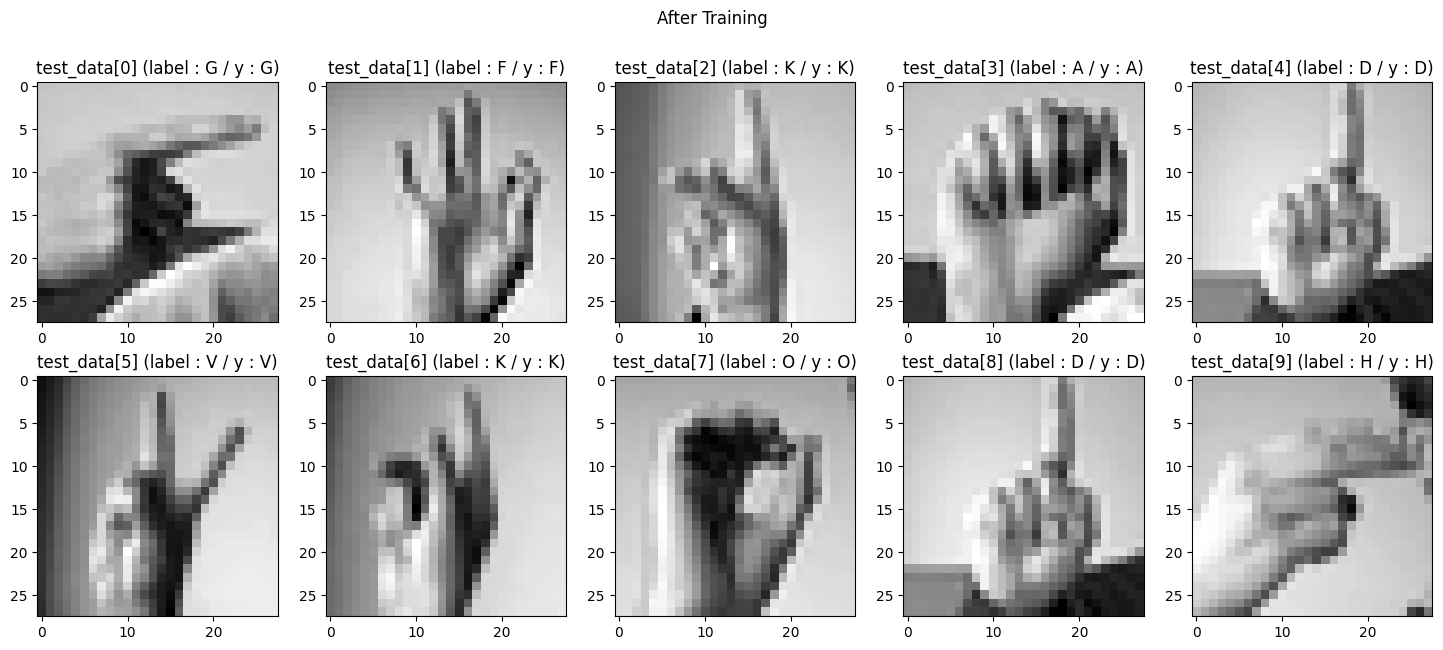

In [15]:
# 9. 학습 후 상황 그리기
y_out = model.predict(test_data[:10])
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)